# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from matplotlib import rcParams
# from plotly.offline import init_notebook_mode
# init_notebook_mode(connected=True)
import plotly.express as px
import warnings
import time
import datetime as dt
warnings.filterwarnings("ignore")
from typing import Optional, Tuple, List, Any
from datasets import load_dataset
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()

# Importing Train, Test and Validation datasets

In [2]:
! gdown 1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
! gdown 1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
! gdown 1dn731As0myZMyq886-XLBfoi29mYxRes
! gdown 1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
! gdown 1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
! gdown 1Az4qS0h_xHgR62O338949jrlwfMal11F

Downloading...
From: https://drive.google.com/uc?id=1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
To: /content/X_train.pkl
100% 12.9M/12.9M [00:00<00:00, 82.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
To: /content/X_val.pkl
100% 4.13M/4.13M [00:00<00:00, 35.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dn731As0myZMyq886-XLBfoi29mYxRes
To: /content/X_test.pkl
100% 4.13M/4.13M [00:00<00:00, 46.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
To: /content/y_train.pkl
100% 1.52M/1.52M [00:00<00:00, 97.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
To: /content/y_val.pkl
100% 506k/506k [00:00<00:00, 106MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Az4qS0h_xHgR62O338949jrlwfMal11F
To: /content/y_test.pkl
100% 506k/506k [00:00<00:00, 109MB/s]


In [3]:
import joblib
X_train = joblib.load('/content/X_train.pkl')
X_test = joblib.load('/content/X_test.pkl')
X_val = joblib.load('/content/X_test.pkl')
y_train = joblib.load('/content/y_train.pkl')
y_test = joblib.load('/content/y_test.pkl')
y_val = joblib.load('/content/y_val.pkl')

# Training Naive Bayes Classifier

In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
nb = MultinomialNB()
param_grid = {
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
}

grid_nb = GridSearchCV(
    estimator = nb,
    param_grid = param_grid,
    cv = 5,
    scoring = "f1",
    n_jobs = -1,
    verbose = 1

)

In [5]:
grid_nb.fit(X_train, y_train)
final_model = grid_nb.best_estimator_
print("Best Params:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params: {'alpha': 5.0}
Best CV Score: 0.7768077988751843


In [6]:
y_val_pred = final_model.predict(X_val)
y_pred = final_model.predict(X_test)

In [7]:
y_pred

array([1, 0, 0, ..., 1, 1, 0])

# Model Evaluation

In [8]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print("Accuarcy of Naive Bayes Classifier:",accuracy_score(y_test, y_pred))
print("Precision of Naive Bayes Classifier:",precision_score(y_test, y_pred))
print("Recall of Naive Bayes Classifier:",recall_score(y_test, y_pred))
print("f1 score of Naive Bayes Classifier:",f1_score(y_test, y_pred))

Accuarcy of Naive Bayes Classifier: 0.7791146855803939
Precision of Naive Bayes Classifier: 0.77279120317095
Recall of Naive Bayes Classifier: 0.7793681495809155
f1 score of Naive Bayes Classifier: 0.7760657421674371


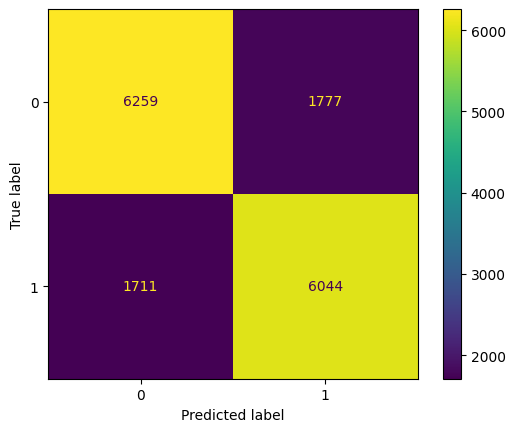

In [9]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.reset_orig()
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=final_model.classes_)
disp.plot()

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78      8036
           1       0.77      0.78      0.78      7755

    accuracy                           0.78     15791
   macro avg       0.78      0.78      0.78     15791
weighted avg       0.78      0.78      0.78     15791



In [12]:
import pickle
import os

model_path = "/content/naive_bayes_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print("Model saved at:", model_path)
print("File exists:", os.path.exists(model_path))

Model saved at: /content/naive_bayes_model.pkl
File exists: True
